In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import sys

print(sys.executable)

c:\Users\Umashree.K.dandin\Desktop\End_to_End_MLProjects\California_house_pricing\.venv\Scripts\python.exe


In [4]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


## Importing the Dataset

In [5]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [6]:
housing.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

## description of the dataset

In [7]:
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block g

In [8]:
print(housing.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## Preparing the Dataset

In [9]:
dataset =pd.DataFrame(housing.data,columns = housing.feature_names)

In [10]:
dataset['price'] = housing.target

In [46]:
dataset.sample(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
8248,1.8036,42.0,5.459893,1.604278,533.0,2.850267,33.78,-118.19,1.75000
4428,1.8750,40.0,4.110266,1.072243,970.0,3.688213,34.09,-118.22,1.50000
19927,5.2561,19.0,6.159645,0.955654,1092.0,2.421286,36.32,-119.33,1.21300
4815,2.0817,41.0,2.272414,1.003448,1224.0,4.220690,34.04,-118.29,1.32500
18069,10.3979,25.0,8.094737,1.035789,1461.0,3.075789,37.29,-122.02,5.00001


### Summerizing the  stats of the data

In [12]:
dataset.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### checking for the missing vakues 

In [13]:
dataset.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
price         0
dtype: int64

### Exploratory Data Analysis
####  1. Correlation

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


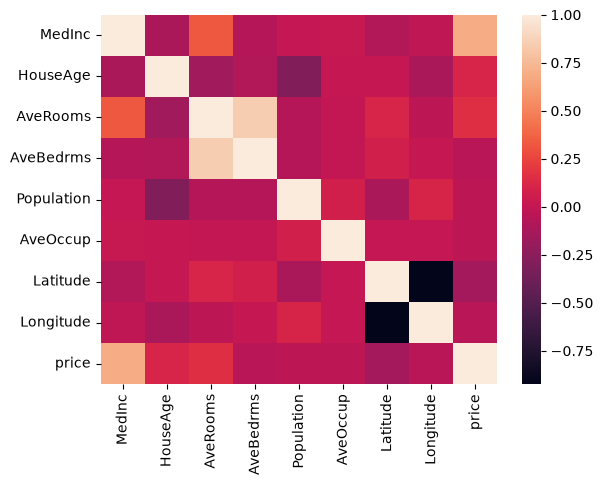

In [14]:
import seaborn as sns
sns.heatmap(dataset.corr())
dataset.corr()

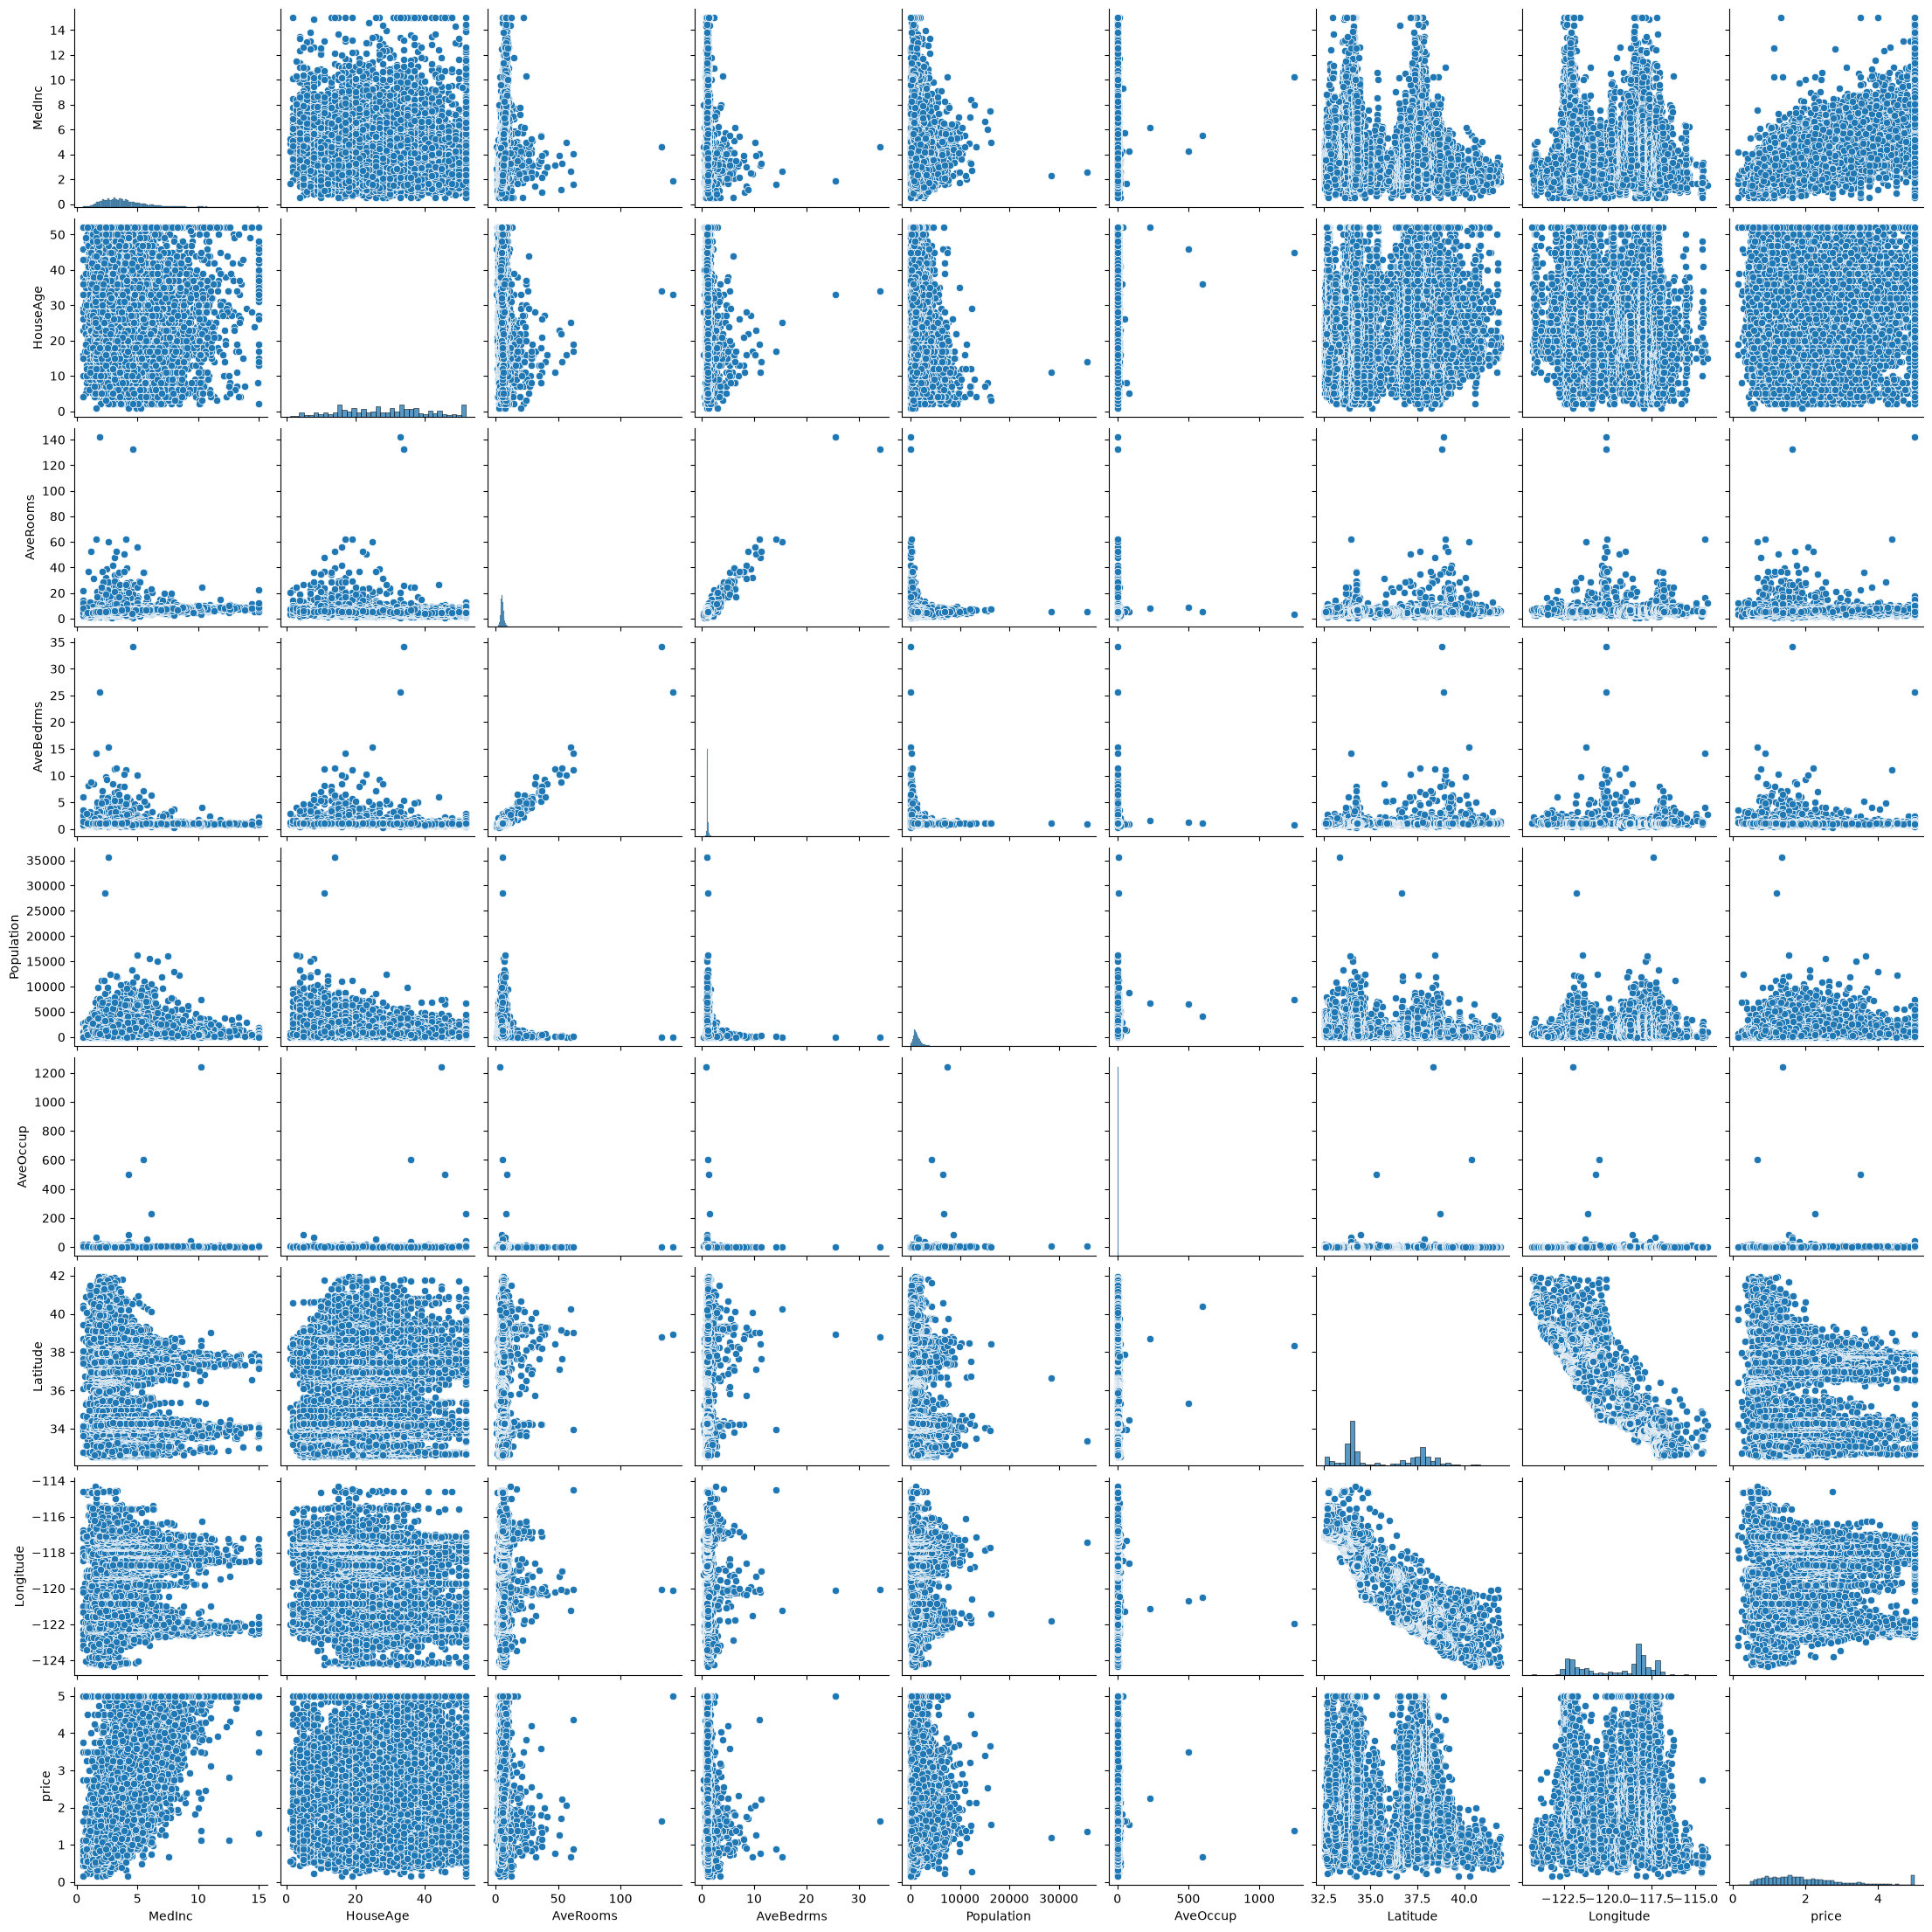

In [15]:
sns.pairplot(dataset)

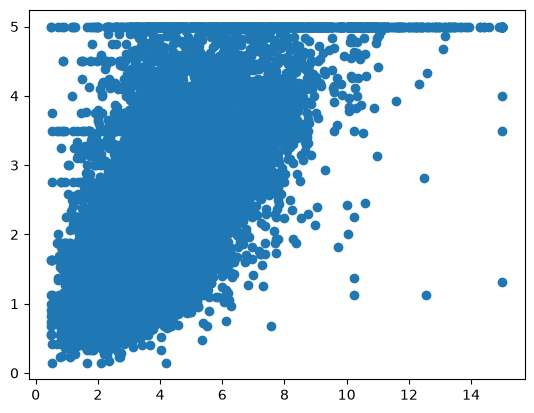

In [16]:
plt.scatter(dataset['MedInc'],dataset['price'])

<Axes: xlabel='MedInc', ylabel='price'>

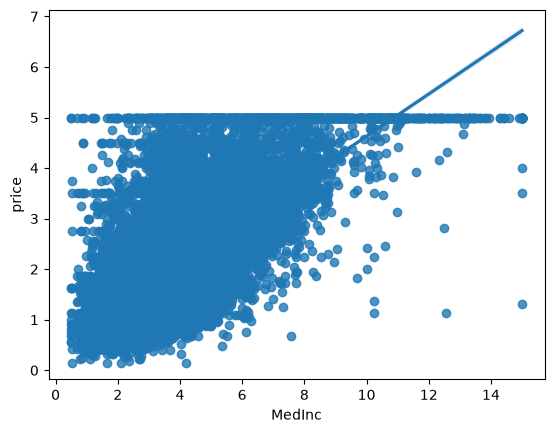

In [17]:
sns.regplot(x='MedInc',y = 'price',data = dataset)

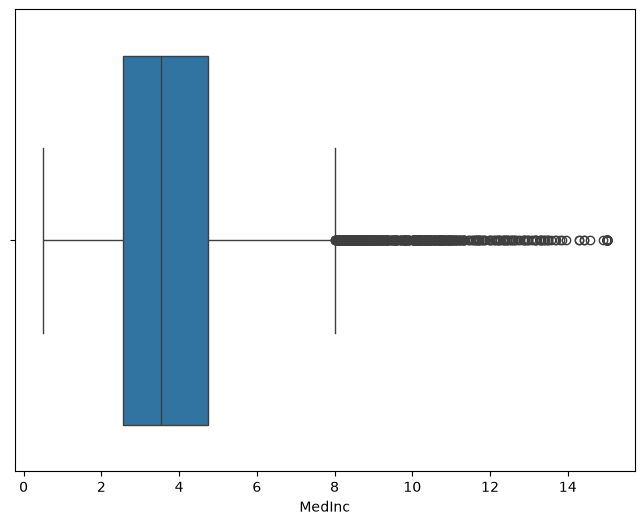

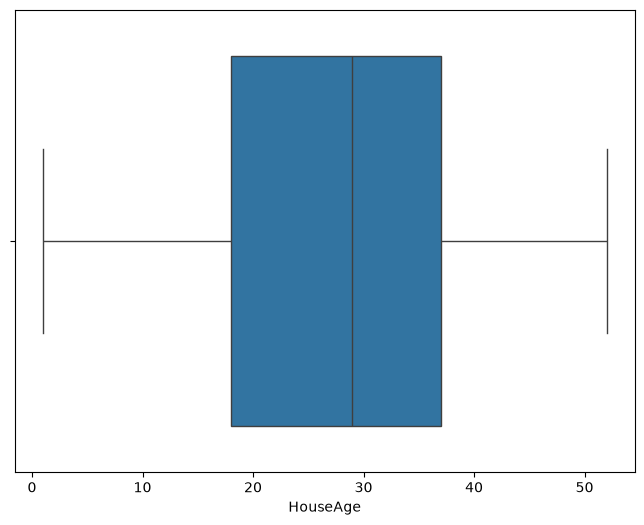

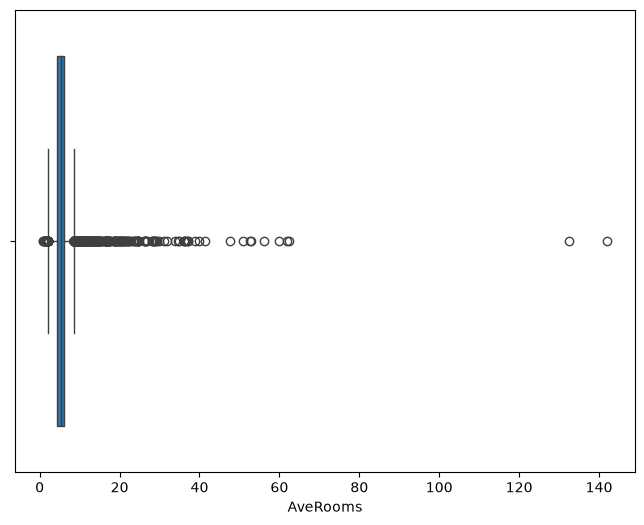

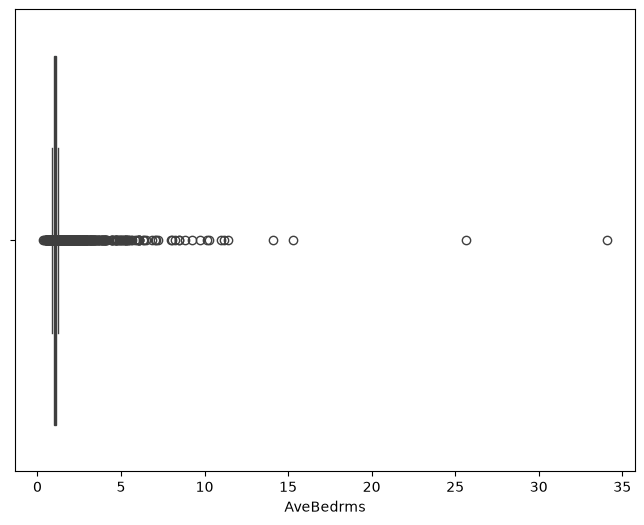

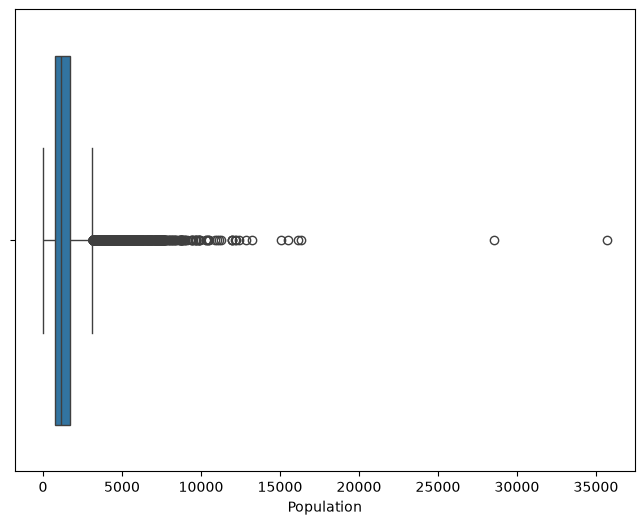

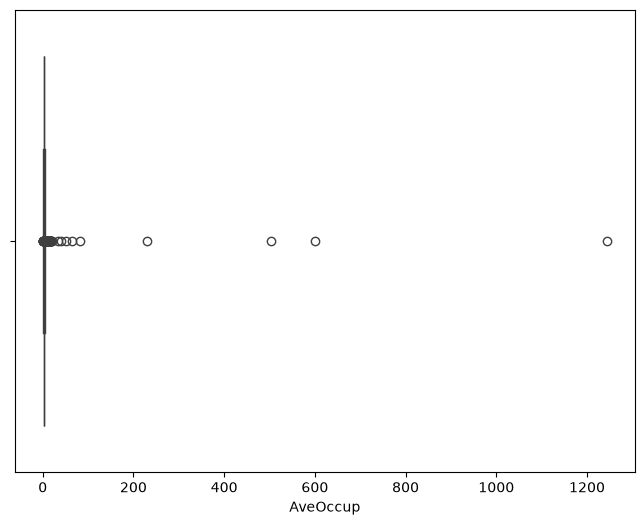

In [18]:
cols = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',]
for i in cols:
    plt.figure(figsize = (8,6))
    sns.boxplot(x= dataset[i])
    plt.show()



### Train Test Split

In [19]:
X = dataset.iloc[:,:-1]
y  = dataset.iloc[:,-1]

In [20]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3,random_state = 42)

#### Applying Standard Scaler 

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [22]:
X_train =scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
import pickle
pickle.dump(scaler,open('scaling.pkl','wb'))

In [24]:
X_test[3]

array([ 0.97683062, -0.91771925,  0.29570668, -0.17393109,  0.24300661,
        0.02628324, -0.64179878,  0.43143401])

### Model Training


In [25]:
from sklearn.linear_model import LinearRegression

In [26]:
linear = LinearRegression()
linear.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.85, 0.12,-0.3 ,...,-0.04,-0.89,-0.87]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.069
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](8,)","[171.11,164.44,135.72,..., 97.49, 34.19, 26.1 ]"


In [27]:
print(linear.coef_)
print(linear.intercept_)

[ 8.49221760e-01  1.22119309e-01 -2.99558449e-01  3.48409673e-01
 -8.84488134e-04 -4.16980388e-02 -8.93855649e-01 -8.68616688e-01]
2.06923960894241


In [28]:
print(linear.get_params())

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}


In [29]:
y_pred =  linear.predict(X_test)

### Model Evaluation

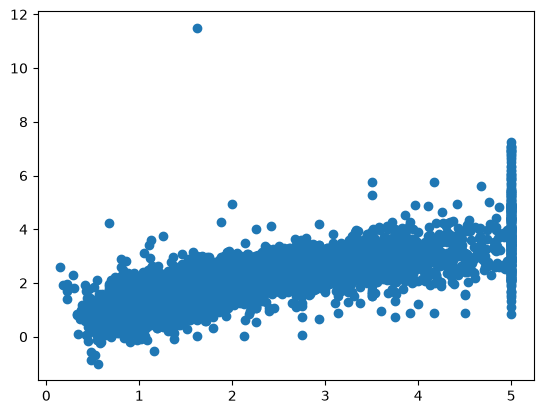

In [30]:
## Scatter plot for a Prediction
plt.scatter(y_test,y_pred)

In [31]:
### Residuals

residuals = y_test - y_pred

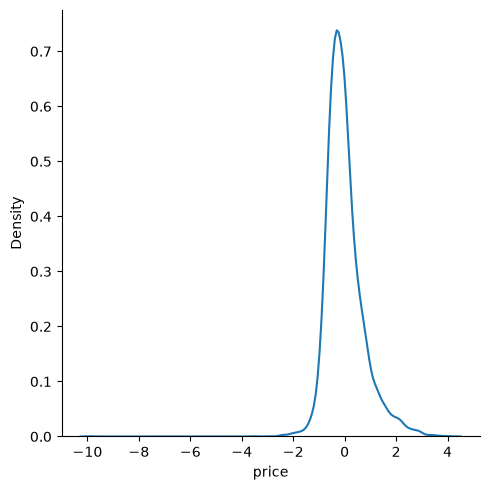

In [32]:
## Plotting the Residuals

sns.displot(residuals,kind ='kde')

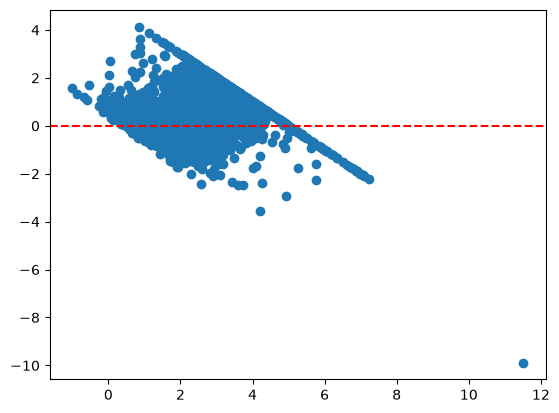

In [33]:
## Scatter plot with respect to prediction and residuals

plt.scatter(y_pred,residuals)
plt.axhline(y=0, color='red', linestyle='--')

In [34]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

print('\n MAE',mean_absolute_error(y_test,y_pred))

print('\n MSE:',mean_squared_error(y_test,y_pred))
print('\n sqrt of MSE',np.sqrt(mean_squared_error(y_test,y_pred)))



 MAE 0.5272474538305951

 MSE: 0.5305677824766752

 sqrt of MSE 0.7284008391515452


### R square and Adjusted R square

In [35]:
score = r2_score(y_test,y_pred)
print(f'\n R2 Score:',score)


 R2 Score: 0.5957702326061665


In [36]:
 1 - (1- score)*(len(y_test)-1)/(len(y_test)- X_test.shape[1]-1)

0.5952472117200027

### New Data Prediction

In [37]:
scaler.transform(housing.data[0].reshape(1,-1))

c:\Users\Umashree.K.dandin\Desktop\End_to_End_MLProjects\California_house_pricing\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[ 2.33526315,  0.98504972,  0.63012521, -0.16586931, -0.96995366,
        -0.04555657,  1.04385626, -1.32105914]])

In [38]:
linear.predict(scaler.transform(housing.data[0].reshape(1,-1)))


c:\Users\Umashree.K.dandin\Desktop\End_to_End_MLProjects\California_house_pricing\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([4.14333441])

In [39]:
housing.data[0].reshape(1,-1)

array([[   8.3252    ,   41.        ,    6.98412698,    1.02380952,
         322.        ,    2.55555556,   37.88      , -122.23      ]])

In [40]:
housing.target[0]

np.float64(4.526)

## Pickling The Model file For Deoloyment

In [41]:
import pickle

In [42]:
pickle.dump(linear,open('regmodel.pkl','wb'))

In [43]:
pickled_model = pickle.load(open('regmodel.pkl','rb'))

In [44]:
pickled_model.predict(scaler.transform(housing.data[0].reshape(1,-1)))

c:\Users\Umashree.K.dandin\Desktop\End_to_End_MLProjects\California_house_pricing\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([4.14333441])